# Fase 3 — Vecinos y jerarquía

**Pregunta:** ¿cómo representar el estado de otros distritos conocido al emitir pronósticos a 2 y 4 semanas? El EDA halló autocorrelación espacial y una asociación entre vecinos con brote y arranques, sin demostrar contagio entre distritos. Se usan centroides del panel y UBIGEO como llave estable.

Los candidatos se calculan en memoria. `frac_con_casos` significa proporción de distritos con más de cero casos; **no** es la marca D1 de brote. Las correlaciones de este notebook son descriptivas y no miden aún la mejora de XGBoost.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import matplotlib.pyplot as plt
import pandas as pd
from src.eda.carga import cargar_integrado
from src.modeling.historia_calendario import construir_historia_calendario
from src.modeling.vecinos_jerarquia import (
    catalogo_geografico, construir_vecinos_jerarquia, matriz_vecindad,
)
from src.utils.paths import DOCS, SILVER_INTEGRADO
from src.validation.expectations_integrado import coverage_path, load_case_coverage, validate_complete

SALIDA = DOCS / "feature_engineering"
METRICAS = SALIDA / "metricas"
FIGURAS = SALIDA / "figuras" / "fase3_vecinos_jerarquia"
METRICAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

## 1. Geografía y pesos

Se reutilizan la distancia de gran círculo y los cinco vecinos uniformes del EDA. Cada matriz tiene diagonal cero y cada fila suma uno. La provincia del distrito viene del panel; sus agregados y los regionales excluyen siempre al propio distrito. Se prueban también `k=3`, `k=8`, pesos inversos dentro de los mismos cinco y pesos inversos entre todos los distritos.

In [2]:
df = cargar_integrado()
cobertura = load_case_coverage(coverage_path(SILVER_INTEGRADO))
validate_complete(df, cobertura)
geo = catalogo_geografico(df)
w5, dist = matriz_vecindad(geo, k=5)
aristas = dist.where(w5 > 0).stack()
vecindad = {
    "distritos": len(geo),
    "provincias": int(geo.provincia.nunique()),
    "vecinos_por_distrito": int((w5 > 0).sum(axis=1).iloc[0]),
    "distancia_arista_mediana_km": round(float(aristas.median()), 2),
    "distancia_arista_min_km": round(float(aristas.min()), 2),
    "distancia_arista_max_km": round(float(aristas.max()), 2),
    "autopeso_max": float(w5.to_numpy().diagonal().max()),
}
assert (w5 > 0).sum(axis=1).eq(5).all()
print(json.dumps(vecindad, ensure_ascii=False, indent=2))

{
  "distritos": 65,
  "provincias": 8,
  "vecinos_por_distrito": 5,
  "distancia_arista_mediana_km": 19.68,
  "distancia_arista_min_km": 4.95,
  "distancia_arista_max_km": 55.89,
  "autopeso_max": 0.0
}


## 2. Contexto disponible en el origen

Para objetivo `t` y horizonte `h`, todas las variables usan `t−h`: media de casos de los cinco vecinos, fracción de vecinos con casos, casos y fracción activa del resto de la provincia, y casos y fracción activa del resto de la región. Las primeras `h` semanas por distrito no tienen origen dentro del panel y quedan en `NaN`. La publicación efectiva de casos no consta en el CSV; se supone provisionalmente disponible al cierre semanal.

In [3]:
features = {h: construir_vecinos_jerarquia(df, h, k=5) for h in (2, 4)}
cobertura_features = {}
for h, f in features.items():
    assert len(f) == len(df)
    assert f[["ubigeo", "anio", "semana"]].equals(df[["ubigeo", "anio", "semana"]])
    assert not f.duplicated(["ubigeo", "anio", "semana"]).any()
    columnas = f.columns[6:]
    cobertura_features[str(h)] = {
        "filas": len(f), "con_contexto": int(f[columnas].notna().all(axis=1).sum()),
        "sin_origen": int(f.origen_inicio.isna().sum()),
    }
print(json.dumps(cobertura_features, indent=2))
features[4].loc[(features[4].ubigeo == "200101") &
    (features[4].anio == 2023) & (features[4].semana == 20)].T

{
  "2": {
    "filas": 30485,
    "con_contexto": 30355,
    "sin_origen": 130
  },
  "4": {
    "filas": 30485,
    "con_contexto": 30225,
    "sin_origen": 260
  }
}


,332
ubigeo,200101
anio,2023
semana,20
semana_inicio,2023-05-14 00:00:00
origen_inicio,2023-04-16 00:00:00
origen_cierre,2023-04-22 00:00:00
vecinos_media_casos_knn5_h4,89.2
vecinos_frac_con_casos_knn5_h4,1.0
provincia_otros_casos_h4,738.0
provincia_otros_frac_con_casos_h4,1.0


In [4]:
objetivo = df[(df.ubigeo == "200101") & (df.anio == 2023) & (df.semana == 20)].iloc[0]
origen = objetivo.semana_inicio - pd.Timedelta(weeks=4)
casos_origen = df.loc[df.semana_inicio == origen].set_index("ubigeo")
vecinos_ejemplo = pd.DataFrame({
    "ubigeo": w5.columns[w5.loc["200101"] > 0],
    "peso": w5.loc["200101", w5.loc["200101"] > 0].to_numpy(),
    "distancia_km": dist.loc["200101", w5.loc["200101"] > 0].to_numpy(),
}).assign(casos_origen=lambda x: x.ubigeo.map(casos_origen.casos_Dengue))
vecinos_ejemplo = vecinos_ejemplo.sort_values("distancia_km").reset_index(drop=True)
vecinos_ejemplo

,ubigeo,peso,distancia_km,casos_origen
0,200115,0.2,10.270040,66
1,200606,0.2,13.559113,17
2,200104,0.2,17.836015,274
3,200602,0.2,21.319734,18
4,200505,0.2,26.951900,71


## 3. Señal descriptiva y sensibilidad de la vecindad

Se calcula correlación de Spearman entre `casos_Dengue` de la semana objetivo y cada variable rezagada, sobre las mismas filas con origen disponible de cada horizonte. Se añade la historia propia de la fase 2 como referencia. Estas asociaciones pueden reflejar la misma temporada y geografía compartida; **no** demuestran transmisión ni mejora predictiva fuera de muestra. Para sensibilidad se compara el valor de la media vecinal bajo otras matrices con `k=5` uniforme.

In [5]:
correlaciones = {}
sensibilidad = {}
for h, f in features.items():
    propia = construir_historia_calendario(df, h)[f"casos_lag_{h}"]
    valido = propia.notna()
    y = df.loc[valido, "casos_Dengue"]
    cols = {
        "historia_propia": propia,
        "vecinos_media_casos": f[f"vecinos_media_casos_knn5_h{h}"],
        "vecinos_frac_con_casos": f[f"vecinos_frac_con_casos_knn5_h{h}"],
        "provincia_otros_casos": f[f"provincia_otros_casos_h{h}"],
        "region_otros_casos": f[f"region_otros_casos_h{h}"],
    }
    correlaciones[str(h)] = {
        "filas": int(valido.sum()),
        "rho_spearman": {nombre: round(float(y.corr(serie[valido], method="spearman")), 4)
                         for nombre, serie in cols.items()},
    }
    base = f[f"vecinos_media_casos_knn5_h{h}"]
    alternativas = {
        "knn3": construir_vecinos_jerarquia(df, h, k=3)[f"vecinos_media_casos_knn3_h{h}"],
        "knn8": construir_vecinos_jerarquia(df, h, k=8)[f"vecinos_media_casos_knn8_h{h}"],
        "knn5_inversa": construir_vecinos_jerarquia(df, h, k=5, metodo="knn_inversa")[f"vecinos_media_casos_knn5_inversa_h{h}"],
        "inversa_todos": construir_vecinos_jerarquia(df, h, metodo="inversa")[f"vecinos_media_casos_inversa_h{h}"],
    }
    sensibilidad[str(h)] = {
        nombre: round(float(base[valido].corr(serie[valido], method="spearman")), 4)
        for nombre, serie in alternativas.items()
    }
print(json.dumps({"correlaciones": correlaciones, "sensibilidad": sensibilidad},
                 ensure_ascii=False, indent=2))

{
  "correlaciones": {
    "2": {
      "filas": 30355,
      "rho_spearman": {
        "historia_propia": 0.7785,
        "vecinos_media_casos": 0.6207,
        "vecinos_frac_con_casos": 0.6171,
        "provincia_otros_casos": 0.5703,
        "region_otros_casos": 0.4743
      }
    },
    "4": {
      "filas": 30225,
      "rho_spearman": {
        "historia_propia": 0.7426,
        "vecinos_media_casos": 0.613,
        "vecinos_frac_con_casos": 0.6076,
        "provincia_otros_casos": 0.562,
        "region_otros_casos": 0.4688
      }
    }
  },
  "sensibilidad": {
    "2": {
      "knn3": 0.872,
      "knn8": 0.8881,
      "knn5_inversa": 0.9986,
      "inversa_todos": 0.7166
    },
    "4": {
      "knn3": 0.8721,
      "knn8": 0.8882,
      "knn5_inversa": 0.9986,
      "inversa_todos": 0.7169
    }
  }
}


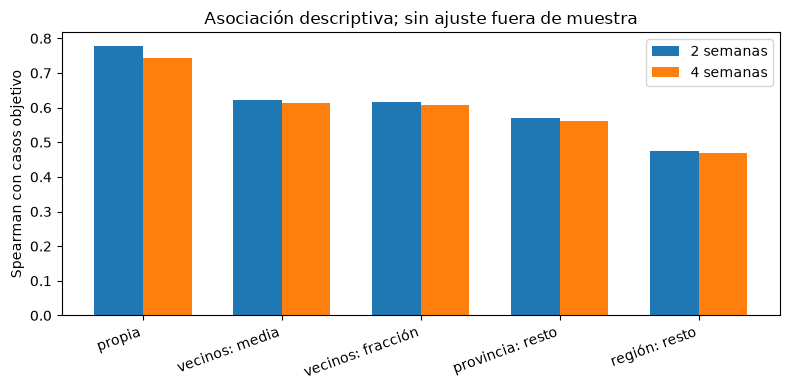

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
nombres = list(correlaciones["2"]["rho_spearman"])
for i, h in enumerate((2, 4)):
    vals = [correlaciones[str(h)]["rho_spearman"][nombre] for nombre in nombres]
    ax.bar([j + (i - .5) * .35 for j in range(len(nombres))], vals,
           width=.35, label=f"{h} semanas")
ax.set_xticks(range(len(nombres)), ["propia", "vecinos: media", "vecinos: fracción",
                                   "provincia: resto", "región: resto"], rotation=20, ha="right")
ax.set(ylabel="Spearman con casos objetivo", title="Asociación descriptiva; sin ajuste fuera de muestra")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURAS / "01_asociacion_contexto.png", dpi=160)
plt.show()

## 4. Registro y límites

La matriz se deriva de centroides del integrado, no de contigüidad o movilidad. El umbral `>0` no reemplaza una definición clínica de brote. Los errores de registro de ceros históricos y la latencia de publicación siguen pendientes. Para saber si vecinos o provincia ayudan a XGBoost hará falta una ablación en cortes temporales; las correlaciones descriptivas no bastan. Las métricas se guardan en `docs/`, sin crear `data/gold/`.

In [7]:
ejemplo = {
    "ubigeo_objetivo": "200101", "anio_objetivo": 2023, "semana_objetivo": 20,
    "semana_origen_h4": str(origen.date()),
    "casos_objetivo": int(objetivo.casos_Dengue),
    "vecinos": [{"ubigeo": str(r.ubigeo), "peso": float(r.peso),
                  "distancia_km": round(float(r.distancia_km), 2),
                  "casos_origen": int(r.casos_origen)}
                 for r in vecinos_ejemplo.itertuples(index=False)],
}
resultado = {
    "entrada": str(SILVER_INTEGRADO.relative_to(ROOT)),
    "filas_panel": len(df), "horizontes": [2, 4],
    "vecindad": vecindad,
    "cobertura_features": cobertura_features,
    "correlaciones_descriptivas": correlaciones,
    "sensibilidad_spearman_vs_knn5": sensibilidad,
    "ejemplo": ejemplo,
    "convenciones": {"corte": "t-h; fecha real de publicación no registrada",
        "vecino_activo": "casos_Dengue > 0; no equivale a D1",
        "provincia_y_region": "excluyen al distrito objetivo",
        "geografia": "centroides del integrado, sin polígonos ni movilidad"},
}
archivo = METRICAS / "fase3_vecinos_jerarquia.json"
archivo.write_text(json.dumps(resultado, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("Métricas guardadas:", archivo)

Métricas guardadas: C:\Users\Rosa\RufoEsEternoElRegreso\Denguekay\docs\feature_engineering\metricas\fase3_vecinos_jerarquia.json
